<a href="https://colab.research.google.com/github/reshmajayaghosh/ICT/blob/main/Linear_Regression_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📓 Linear Regression from Scratch

### 🎯 Objective
- Implement a linear regression model using gradient descent.
- Derive the gradient updates, write a scikit-learn-like class, and evaluate using synthetic data.
- Compare the result of the same with library code output
- Use R2-Score and Mean Absolute Percentage error as Performance metric on test data

## 📊 Generate Synthetic Data

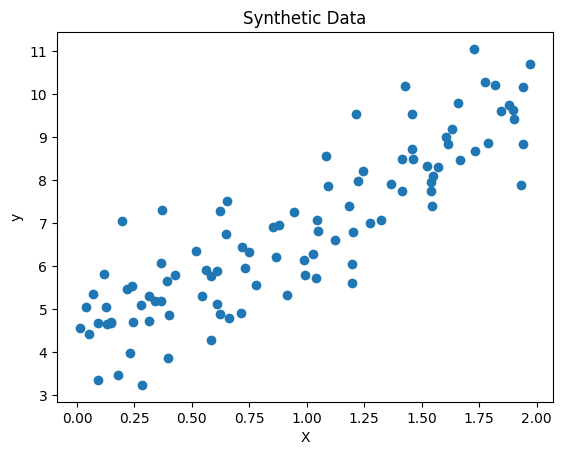

In [49]:

import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Plot
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data")
plt.show()


## Do Train-Test Split (75%-25%)

In [50]:
# Write your code here
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 42)

In [51]:
X_train.shape

(75, 1)

In [52]:
X_test.shape

(25, 1)

In [53]:
y_train.shape

(75, 1)

In [54]:
y_test.shape

(25, 1)

## Do the Linear Regression with Scikit-Learn Library

In [55]:
# Write your code here
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

array([[4.51529213],
       [9.04715953],
       [8.37887044],
       [7.78069133],
       [5.57959087],
       [6.56838772],
       [5.76148655],
       [8.87420875],
       [4.28100959],
       [6.21068572],
       [6.52364265],
       [7.48096833],
       [8.61447668],
       [9.34187103],
       [4.8207856 ],
       [5.01936214],
       [8.37355813],
       [4.57246078],
       [8.70705394],
       [5.09844235],
       [9.19461227],
       [9.00564662],
       [5.25735888],
       [4.35626563],
       [9.549045  ]])

In [56]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error
r2_score(y_test, y_pred)


0.8310990846073661

In [57]:
mean_absolute_percentage_error(y_test, y_pred)

0.08475682819153892

## Do Ridge and Lasso Regression and Compare the evaluation metrics in a table

In [58]:
# Write your code here

`Lasso Regression`

In [59]:
from sklearn.linear_model import Lasso

In [60]:
lasso_model = Lasso(alpha = 0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)


In [61]:
r2_score(y_test,y_pred_lasso)

0.8090816688640925

In [62]:
mean_squared_error(y_test,y_pred_lasso)

0.7992315675731249

In [63]:
mean_absolute_percentage_error(y_test,y_pred_lasso)

0.08264002206148635

`Ridge Regression`

In [64]:
from sklearn.linear_model import Ridge

In [65]:
ridge_model = Ridge(alpha = 0.1)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)


In [66]:
r2_score(y_test,y_pred_ridge)

0.8306977946096742

In [67]:
mean_squared_error(y_test,y_pred_ridge)

0.7087410947007179

In [68]:
mean_absolute_percentage_error(y_test,y_pred_ridge)

0.08451338266857177

## Custom Implementation

## 🧮 Derive the Gradient Updates
Use the chain rule to derive the gradients of the loss function (Mean Square Error):

$$ \text{Loss} = \frac{1}{N} \sum_{i=1}^{N} (y_i - (mx_i + c))^2 $$

Derive:
- ∂Loss/∂m
- ∂Loss/∂c

Write the derivation here/add screenshot of your derivation here:

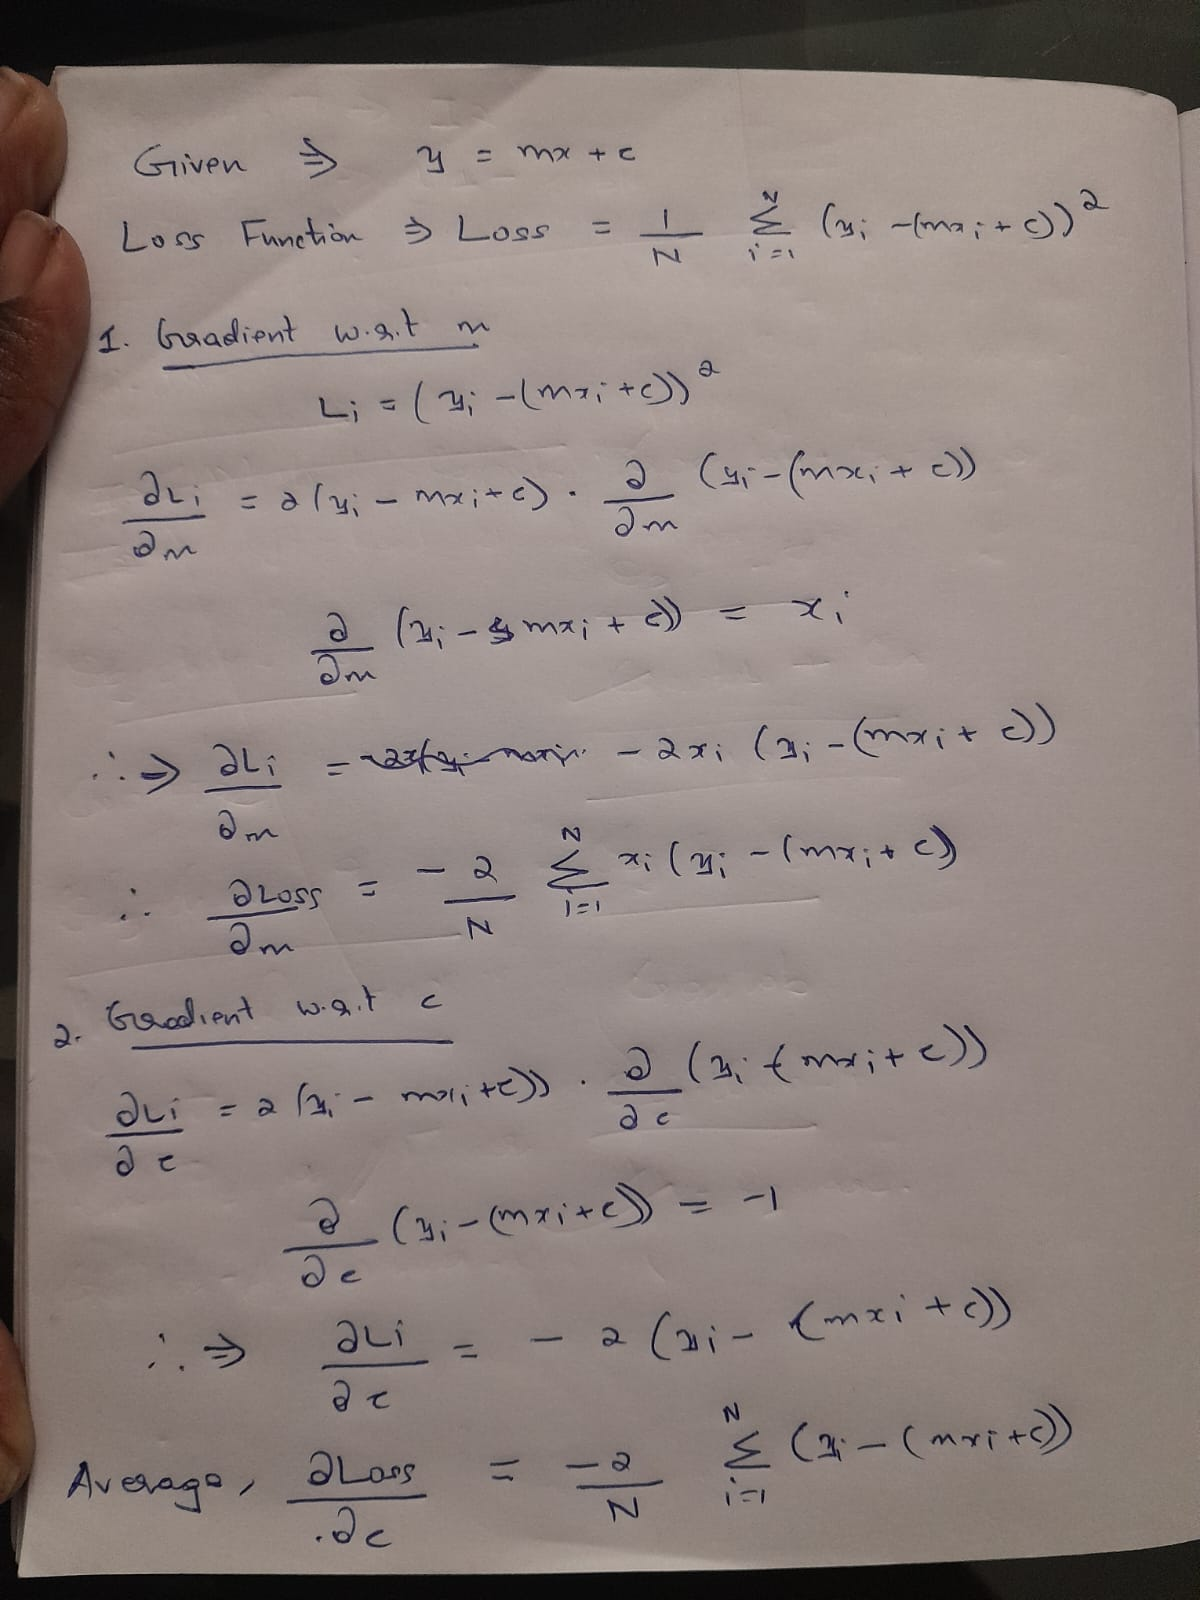

## 🧠 Custom Linear Regression Class

In [69]:

class MyLinearRegression:
    def __init__(self):
      self.m = 0
      self.c = 0
      self.coef_ = None
      self.intercept_ = None
      self.losses = []


    def fit(self, X, y, lr=0.01, n_iters=1000):
      X = np.array(X)
      y = np.array(y)
      n = len(X)

      for _ in range(n_iters):
            y_pred = self.m * X + self.c


            loss = (1/n) * np.sum((y - y_pred) ** 2)
            self.losses.append(loss)

            dm = (-2/n) * np.sum(X * (y - y_pred))
            dc = (-2/n) * np.sum(y - y_pred)


            self.m -= lr * dm
            self.c -= lr * dc

      self.coef_ = np.array([self.m])
      self.intercept_ = self.c

    def predict(self, X):
      X = np.array(X)
      return self.m * X + self.c

    def fit_transform(self, X, y, lr=0.01, n_iters=1000):
      self.fit(X, y, lr, n_iters)
      return self.predict(X)



## 🔁 Train the Model and Visualize the Fit

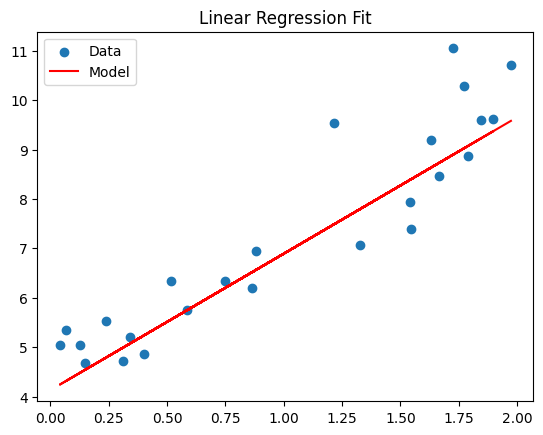

Learned coefficients (m, c): [[2.72587297]]
Learned coefficients (m, c): [2.72587297] [4.16878815]


In [70]:

model_custom = MyLinearRegression()
model_custom.fit(X_train, y_train, lr=0.1, n_iters=100)
y_pred_custom = model_custom.predict(X_test)

plt.scatter(X_test, y_test, label="Data")
plt.plot(X_test, y_pred_custom, color="red", label="Model")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()


print("Learned coefficients (m, c):", model.coef_)
print("Learned coefficients (m, c):", model.coef_[0], model.intercept_)


## 📉 Plot the Loss Curve

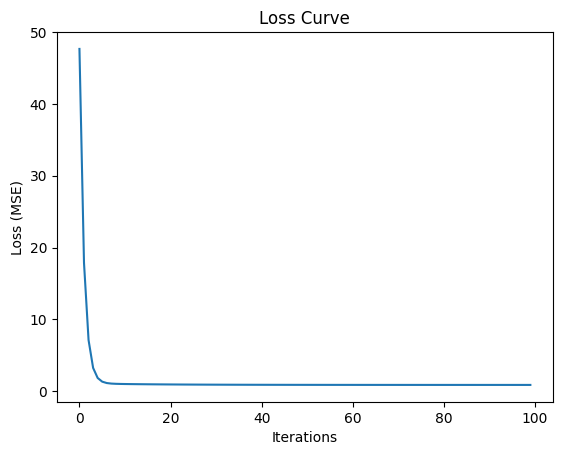

In [71]:
# Write your code here

plt.plot(model_custom.losses)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve")
plt.show()

## 🌟 Bonus Task: Stochastic Gradient Descent
Implement a class `MyLinearRegressionSGD` that uses one training sample per iteration to update weights.

In [72]:
# Write your code here

class MyLinearRegressionSGD:
    def __init__(self):
        self.m = 0.0
        self.c = 0.0
        self.losses = []

    def fit(self, X, y, lr=0.01, n_iters=100):
        X = np.array(X)
        y = np.array(y)
        n = len(X)

        for _ in range(n_iters):
            for i in range(n):
                xi = X[i]
                yi = y[i]


                y_pred = self.m * xi + self.c


                loss = (yi - y_pred) ** 2
                self.losses.append(loss)


                dm = -2 * xi * (yi - y_pred)
                dc = -2 * (yi - y_pred)


                self.m -= lr * dm
                self.c -= lr * dc

    def predict(self, X):
        X = np.array(X)
        return self.m * X + self.c

In [73]:

model_sgd = MyLinearRegressionSGD()
model_sgd.fit(X_train, y_train, lr=0.01, n_iters=50)

y_pred_sgd = model_sgd.predict(X_test)

print("Slope (m):", model_sgd.m)
print("Intercept (c):", model_sgd.c)

Slope (m): [2.76590168]
Intercept (c): [4.1888505]


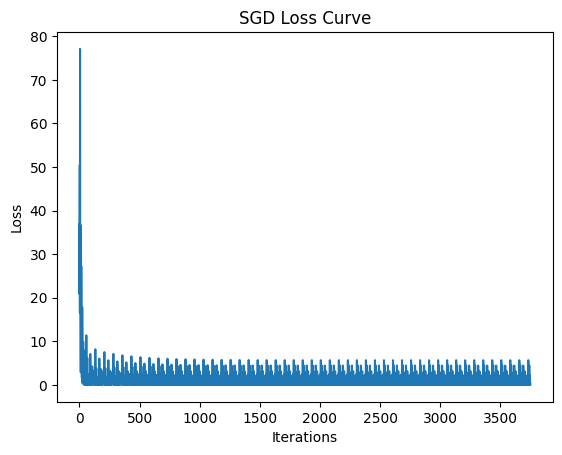

In [74]:
# Plot loss curve while using Stochastic Gradient Descent


plt.plot(model_sgd.losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("SGD Loss Curve")
plt.show()

## Visualize the prediction result of Library version and Custom regression code created

In [75]:
# Write your code here

sorted_idx = np.argsort(X_test.flatten())

X_test_sorted = X_test.flatten()[sorted_idx]
y_test_sorted = y_test.flatten()[sorted_idx]

y_pred_sklearn_sorted = y_pred.flatten()[sorted_idx]
y_pred_custom_sorted = y_pred_custom.flatten()[sorted_idx]
y_pred_sgd_sorted = y_pred_sgd.flatten()[sorted_idx]

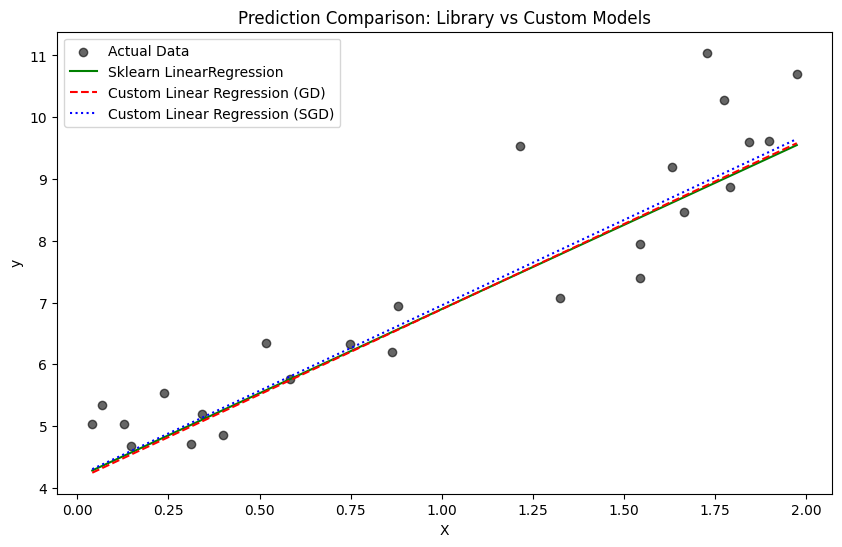

In [76]:
plt.figure(figsize=(10, 6))

plt.scatter(X_test, y_test, color="black", label="Actual Data", alpha=0.6)

# Sklearn model
plt.plot(X_test_sorted, y_pred_sklearn_sorted,
         color="green", label="Sklearn LinearRegression")

# Custom Batch GD
plt.plot(X_test_sorted, y_pred_custom_sorted,
         color="red", linestyle="--", label="Custom Linear Regression (GD)")

# Custom SGD
plt.plot(X_test_sorted, y_pred_sgd_sorted,
         color="blue", linestyle=":", label="Custom Linear Regression (SGD)")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Prediction Comparison: Library vs Custom Models")
plt.legend()
plt.show()

## ✅ Checklist
- [ ] Did linear regression using scikit-learn API
- [ ] Did Ridge and Lasso regression and compiled the result (R2 and MAPE) as a table
- [ ] Derived gradients using chain rule
- [ ] Implemented custom Linear Regression class
- [ ] Trained using gradient descent
- [ ] Visualized predictions and loss
- [ ] Implemented stochastic gradient descent (bonus)
- [ ] Visualized predictions and loss for stochastic gradient descent (bonus)
- [ ] Visualize the prediction result of Library version and custom version